# Notebook for setting up and analysing CICE6 
### This will serve as my python notebook for sharing
After establishing that CICE6 'gx1' and 'gx3' grids run through to completion on the 'vanilla' setup (see https://github.com/dpath2o/AFIM/blob/main/MODELS/cice.org). The 'tx1' runs to completion but appears to not read-in the forcing data as all the data variables in 'history' file output are 'nan'. At this stage I think the way forward is:
1. create a cartesian grid using an example from either ACCESS-OM2 or other sources online
2. create bathymetry on the same grid scale
3. create forcing on the same grid scale
4. create initial conditions on the same grid scale

In [1]:
import os
import warnings
import cartopy
import cartopy.crs       as ccrs
import matplotlib.pyplot as plt
import matplotlib        as mpl
import xarray            as xr
import pandas            as pd
import numpy             as np
import metpy.calc        as mpc
from xgcm                    import Grid
from matplotlib.ticker       import MaxNLocator
from datetime                import datetime, timedelta
from mpl_toolkits.axes_grid1 import make_axes_locatable,Divider,Size
from cartopy.mpl.gridliner   import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
%matplotlib inline
warnings.filterwarnings("ignore")

## The 'vanilla' CICE6 run output
These three history files were output from the three grids available from CICE6 (https://cice-consortium-cice.readthedocs.io/en/master/index.html)

In [21]:
gx1 = xr.open_dataset('/Users/dpath2o/cice-dirs/runs/sandbox_gx1/history/iceh_ic.2005-01-01-03600.nc')
tx1 = xr.open_dataset('/Users/dpath2o/cice-dirs/runs/sandbox_tx1/history/iceh_ic.2005-01-01-03600.nc')
gx3 = xr.open_dataset('/Users/dpath2o/cice-dirs/runs/sandbox_gx3/history/iceh_ic.2005-01-01-03600.nc')

## ACCESS-OM2 grid file (courtesy of Paul)

In [2]:
nc1 = xr.open_dataset('/Users/dpath2o/PHD/MODELS/CICE_runs/grids/cice_1deg_grid_from_paul.nc')

## Following this ( https://gallery.pangeo.io/repos/xgcm/xgcm-examples/03_MOM6.html ) example

In [16]:
dataurl = 'http://35.188.34.63:8080/thredds/dodsC/OM4p5/ocean_monthly_z.200301-200712.nc4'
om4p5   = xr.open_dataset(f'{dataurl}',
                          chunks={'time':1, 'z_l': 1}, drop_variables=['average_DT',
                                                                       'average_T1',
                                                                       'average_T2'],
                          engine='netcdf4')
#grid = Grid(om4p5, coords={'X': {'center': 'xh', 'outer': 'xq'},
#                            'Y': {'center': 'yh', 'outer': 'yq'},
#                            'Z': {'inner': 'z_l', 'outer': 'z_i'} }, periodic=['X'
om4p5

<xarray.Dataset>
Dimensions:       (nv: 2, xh: 720, xq: 720, yh: 576, yq: 576, z_i: 36, z_l: 35,
                   time: 60)
Coordinates:
  * nv            (nv) float64 1.0 2.0
  * xh            (xh) float64 -299.8 -299.2 -298.8 -298.2 ... 58.75 59.25 59.75
  * xq            (xq) float64 -299.5 -299.0 -298.5 -298.0 ... 59.0 59.5 60.0
  * yh            (yh) float64 -77.91 -77.72 -77.54 -77.36 ... 89.47 89.68 89.89
  * yq            (yq) float64 -77.82 -77.63 -77.45 -77.26 ... 89.58 89.79 90.0
  * z_i           (z_i) float64 0.0 5.0 15.0 25.0 ... 5.75e+03 6.25e+03 6.75e+03
  * z_l           (z_l) float64 2.5 10.0 20.0 32.5 ... 5.5e+03 6e+03 6.5e+03
  * time          (time) object 2003-01-16 12:00:00 ... 2007-12-16 12:00:00
Data variables: (12/36)
    Coriolis      (yq, xq) float32 dask.array<chunksize=(576, 720), meta=np.ndarray>
    areacello     (yh, xh) float32 dask.array<chunksize=(576, 720), meta=np.ndarray>
    areacello_bu  (yq, xq) float32 dask.array<chunksize=(576, 720), meta=np.ndarray>
    areacello_cu  (yh, xq) float32 dask.array<chunksize=(576, 720), meta=np.ndarray>
    areacello_cv  (yq, xh) float32 dask.array<chunksize=(576, 720), meta=np.ndarray>
    deptho        (yh, xh) float32 dask.array<chunksize=(576, 720), meta=np.ndarray>
    ...            ...
    umo           (time, z_l, yh, xq) float32 dask.array<chunksize=(1, 1, 576, 720), meta=np.ndarray>
    uo            (time, z_l, yh, xq) float32 dask.array<chunksize=(1, 1, 576, 720), meta=np.ndarray>
    vmo           (time, z_l, yq, xh) float32 dask.array<chunksize=(1, 1, 576, 720), meta=np.ndarray>
    vo            (time, z_l, yq, xh) float32 dask.array<chunksize=(1, 1, 576, 720), meta=np.ndarray>
    volcello      (time, z_l, yh, xh) float32 dask.array<chunksize=(1, 1, 576, 720), meta=np.ndarray>
    zos           (time, yh, xh) float32 dask.array<chunksize=(1, 576, 720), meta=np.ndarray>
Attributes:
    filename:                        ocean_monthly.200301-200712.zos.nc
    title:                           OM4p5_IAF_BLING_CFC_abio_csf_mle200
    associated_files:                areacello: 20030101.ocean_static.nc
    grid_type:                       regular
    grid_tile:                       N/A
    external_variables:              areacello
    DODS_EXTRA.Unlimited_Dimension:  time

## My attempt at creating a CICE6-compatible grid from the MOM6

In [20]:
Gout = xr.Dataset(coords=dict(TLON=(["nj","ni"], -om4p5.geolon.values),
                              TLAT=(["nj","ni"], om4p5.geolat.values),
                              ULON=(["ny","nx"],-om4p5.geolon_c.values),
                              ULAT=(["ny","nx"],om4p5.geolat.values)),
                  attrs=dict(description="0.5 degree c-grid from MOM6"))
Gout.to_netcdf("/Users/dpath2o/cice-dirs/input/CICE_data/grid/gx0p5/grid_px0p5.nc")

## Plotting the grids

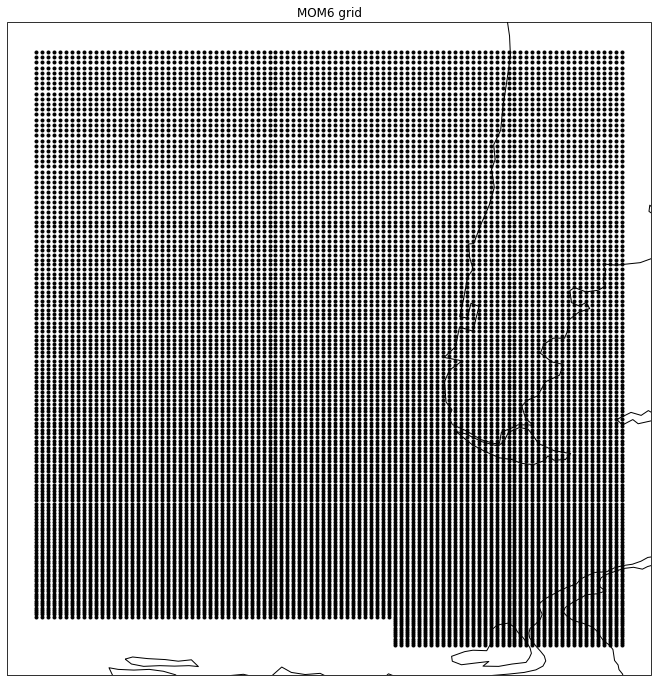

In [24]:
fig = plt.figure(figsize=(15,12))
ax  = plt.axes(projection=ccrs.PlateCarree())
lons = -om4p5.isel(xh=slice(1,100),yh=slice(1,200)).geolon
lats = om4p5.isel(xh=slice(1,100),yh=slice(1,200)).geolat
plt.plot(lons,lats,transform=ccrs.PlateCarree(),marker='.',linestyle='none',color='k')
ax.coastlines()
tit_str = 'MOM6 grid'.format()
plt.title(tit_str)
plt.show()
plt.close(fig)

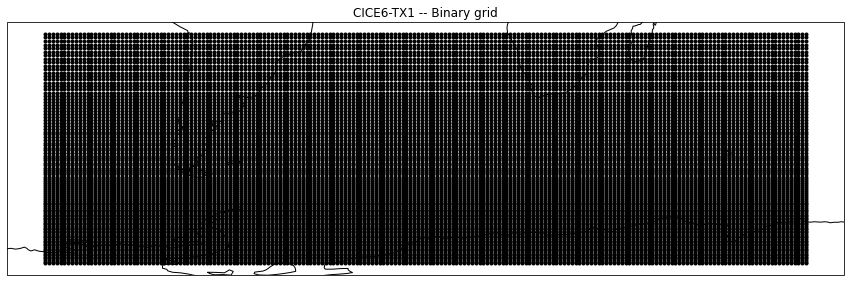

In [8]:
fig = plt.figure(figsize=(15,12))
ax  = plt.axes(projection=ccrs.PlateCarree())
lons = tx1.isel(nj=slice(1,100),ni=slice(1,200)).TLON
lats = tx1.isel(nj=slice(1,100),ni=slice(1,200)).TLAT
plt.plot(lons,lats,transform=ccrs.PlateCarree(),marker='.',linestyle='none',color='k')
ax.coastlines()
tit_str = 'CICE6-TX1 -- Binary grid'.format()
plt.title(tit_str)
plt.show()
plt.close(fig)

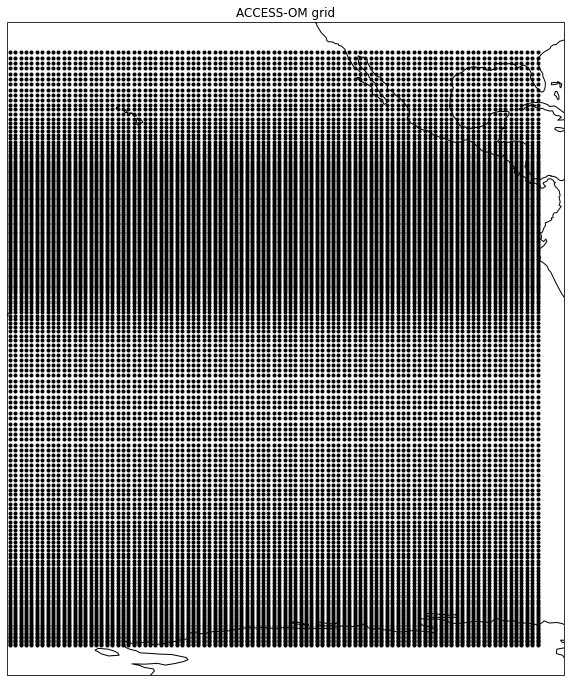

In [23]:
fig = plt.figure(figsize=(15,12))
ax  = plt.axes(projection=ccrs.PlateCarree())
lons = -np.rad2deg(nc1.isel(nx=slice(1,100),ny=slice(1,200)).tlon)
lats = np.rad2deg(nc1.isel(nx=slice(1,100),ny=slice(1,200)).tlat)
plt.plot(lons,lats,transform=ccrs.PlateCarree(),marker='.',linestyle='none',color='k')
ax.coastlines()
tit_str = 'ACCESS-OM grid'.format()
plt.title(tit_str)
plt.show()
plt.close(fig)

# Get forcing data onto the higher-resolution

In [65]:
#just opening one of the many tarred files downloaded from UCAR 
lsrr01 = xr.open_mfdataset("/Users/dpath2o/cice-dirs/568229.LSRR.e5.oper.fc.sfc.instan.228_219_lsrr.ll025sc.2010010106_2010011606-2012011606_2012020106/*.nc",engine='netcdf4')
lsrr01

,Array,Chunk
Bytes,19.69 GiB,423.98 MiB
Shape,"(1522, 12, 201, 1440)","(32, 12, 201, 1440)"
Count,150 Tasks,50 Chunks
Type,float32,numpy.ndarray
